# 05 - Model Comparison

Physically verify AI predictions (`src.ai.physical_verification`) and compare accuracy, reliability, cost, and computational efficiency across all models and the mechanistic reference.


**Status:** placeholder created in Stage 1 (project scaffold). Populated in Stage 7 (physical AI verification) and Stage 9 (final comparison).

This notebook is intentionally thin: it should only call reusable functions from `src/`, never contain modelling logic itself (PROJECT_BRIEF.md §25, §1.6).


In [1]:
# Colab-aware bootstrap: on Google Colab, clone the repo (or pull the latest
# commits into an existing clone) and install dependencies automatically --
# no manual setup cell needed. Locally / outside Colab, this only fixes
# sys.path, exactly as before.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sulhos/Leonardo-Assignment.git"
BRANCH = "claude/repository-project-prompt-or0ida"
REPO_DIRNAME = "Leonardo-Assignment"
MARKER_FILE = "PROJECT_BRIEF.md"  # present only at the real project root

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    search_dirs = [Path.cwd(), Path.cwd() / REPO_DIRNAME]
    repo_root = next((d for d in search_dirs if (d / MARKER_FILE).is_file()), None)

    if repo_root is None:
        print(f"Cloning {REPO_URL} (branch {BRANCH})...")
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
        repo_root = Path.cwd() / REPO_DIRNAME
    else:
        print(f"Found existing clone at {repo_root} -- hard-syncing to origin/{BRANCH}...")
        # Hard sync (fetch + reset --hard), not `git pull`: a plain pull can leave
        # a Colab VM's reused (not freshly cloned) checkout on stale tracked files
        # if the local branch has drifted or a merge doesn't fast-forward cleanly --
        # this bit twice (stale `src/` imports surviving a "fresh" notebook run on a
        # reconnected-but-not-recreated Colab runtime). Fetch+reset always makes the
        # tracked files exactly match origin/BRANCH; it never touches untracked/
        # gitignored files (e.g. the cached weather downloads), so nothing is lost.
        subprocess.run(["git", "fetch", "origin", BRANCH], check=True, cwd=str(repo_root))
        subprocess.run(["git", "reset", "--hard", f"origin/{BRANCH}"], check=True, cwd=str(repo_root))

    os.chdir(repo_root)
    PROJECT_ROOT = Path.cwd()
    print(f"Working directory: {PROJECT_ROOT}")

    # Skip jupyter/ipykernel: Colab already provides its own pinned versions,
    # and reinstalling them can destabilize the running kernel.
    requirements = [
        line for line in Path("requirements.txt").read_text().splitlines()
        if line.strip() and not line.strip().startswith("#")
        and not line.lower().startswith(("jupyter", "ipykernel"))
    ]
    req_path = Path("/tmp/requirements_colab.txt")
    req_path.write_text("\n".join(requirements))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(req_path)], check=True)
    print("Dependencies installed.")
else:
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import time
import pandas as pd
from tensorflow import keras

from src.config import load_site_config, load_yaml_config
from src.data.weather import get_processed_weather
from src.ai.features import build_feature_matrix
from src.ai.splitting import split_experiment_a
from src.ai.baselines import fit_linear_baseline, fit_naive_baseline, fit_tree_baseline
from src.ai.preprocessing import load_preprocessing_objects
from src.ai.neural_network import load_trained_model
from src.ai.neural_network import predict as nn_predict
from src.ai.physical_verification import summarize_verification, verify_predictions
from src.visualization.plotting import (
    plot_accuracy_runtime_tradeoff, plot_cost_penalty_from_oversizing,
    plot_reliability_pass_rate_by_model, plot_runtime_comparison, save_figure,
)

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
MODELS_DIR = PROJECT_ROOT / "models"
ml_cfg = load_yaml_config("ml_training")
site_config = load_site_config("jinan")

I0000 00:00:1784480916.539972    6661 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784480916.540541    6661 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784480916.601994    6661 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784480917.958207    6661 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784480917.958724    6661 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Rebuild the identical data/features/split used in Stages 5 and 6

**Note on merging:** `build_feature_matrix` already carries `pv_capacity_kwp`, `wind_capacity_kw`, `annual_load_kwh`, `peak_load_kw`, `reliability_target_load_served`, `round_trip_efficiency`, and `usable_soc_window_fraction` as pass-through features -- only merge in the genuinely new columns from the raw scenario table (`optimal_capacity_kwh`, `optimal_n_modules`, `weather_year`, `timezone`, `random_seed`), or pandas silently suffixes the duplicates with `_x`/`_y`.

In [3]:
scenarios = pd.read_csv(PROJECT_ROOT / "data" / "scenarios" / "pilot_scenarios.csv")
feasible = scenarios[scenarios["feasible"]].reset_index(drop=True)
weather = get_processed_weather("jinan", 2023)
features = build_feature_matrix(feasible, weather, site_config)

extra_cols = ["scenario_id", "optimal_capacity_kwh", "optimal_n_modules", "weather_year", "timezone", "random_seed"]
merged = features.merge(feasible[extra_cols], on="scenario_id")
feature_columns = [c for c in features.columns if c != "scenario_id"]

splits = split_experiment_a(merged, group_column="scenario_id", random_seed=ml_cfg["random_seed"])
X_train, y_train = merged.loc[splits["train"], feature_columns], merged.loc[splits["train"], "optimal_capacity_kwh"]
X_val, y_val = merged.loc[splits["val"], feature_columns], merged.loc[splits["val"], "optimal_capacity_kwh"]
X_test, y_test = merged.loc[splits["test"], feature_columns], merged.loc[splits["test"], "optimal_capacity_kwh"]
test_scenarios = merged.loc[splits["test"]]
print({k: len(v) for k, v in splits.items()})

{'train': 39, 'val': 8, 'test': 9}


## Get predictions from all four models on the test split

Baselines are retrained fresh (fast, deterministic given the fixed seed). The neural network is **loaded from its Stage 6 saved artifacts** (`models/neural_network/best_model.weights.h5`, `models/preprocessing/scaler.pkl`) rather than retrained, so this notebook verifies the actual model that was saved, not a fresh (potentially slightly different) training run. Weights are loaded into a freshly-built architecture (`load_trained_model`) rather than via `keras.models.load_model` on the full `.keras` file, since the latter is not portable across Keras versions (it serializes layer-initializer configs, which broke loading on Colab's older pinned Keras against artifacts saved with a newer one) -- see `src/ai/neural_network.py`'s `train_model` docstring.

In [4]:
train_times = {}
inference_seconds = {}
predictions_by_model = {}

t0 = time.perf_counter(); naive_model = fit_naive_baseline(X_train, y_train); train_times["naive"] = time.perf_counter() - t0
t0 = time.perf_counter(); ridge_model = fit_linear_baseline(X_train, y_train, X_val, y_val, ml_cfg["baselines"]["linear"]["alpha_grid"]); train_times["ridge"] = time.perf_counter() - t0
t0 = time.perf_counter(); rf_model = fit_tree_baseline(X_train, y_train, X_val, y_val, ml_cfg["baselines"]["tree"]["n_estimators_grid"], ml_cfg["baselines"]["tree"]["max_depth_grid"]); train_times["random_forest"] = time.perf_counter() - t0

for name, model in [("naive", naive_model), ("ridge", ridge_model), ("random_forest", rf_model)]:
    t0 = time.perf_counter()
    predictions_by_model[name] = pd.Series(model.predict(X_test), index=X_test.index)
    inference_seconds[name] = (time.perf_counter() - t0) / len(X_test)

preprocessing = load_preprocessing_objects(MODELS_DIR / "preprocessing")
nn_scaler = preprocessing["scaler"]
nn_feature_columns = preprocessing["feature_columns"]
nn_model = load_trained_model(len(nn_feature_columns), ml_cfg["neural_network"], MODELS_DIR / "neural_network" / "best_model.weights.h5")

X_test_scaled = pd.DataFrame(nn_scaler.transform(X_test[nn_feature_columns]), columns=nn_feature_columns, index=X_test.index)
t0 = time.perf_counter()
predictions_by_model["neural_network"] = pd.Series(nn_predict(nn_model, X_test_scaled), index=X_test.index)
inference_seconds["neural_network"] = (time.perf_counter() - t0) / len(X_test)
train_times["neural_network"] = None  # trained in Stage 6, not retrained here

{name: preds.round(1).tolist() for name, preds in predictions_by_model.items()}

E0000 00:00:1784480923.413592    6661 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


{'naive': [92.2, 92.2, 92.2, 92.2, 92.2, 92.2, 92.2, 92.2, 92.2],
 'ridge': [218.1, 236.7, 109.9, 195.7, 207.9, 171.4, 240.8, 157.0, 400.6],
 'random_forest': [266.2,
  265.6,
  131.8,
  149.9,
  165.5,
  140.4,
  175.4,
  136.8,
  276.0],
 'neural_network': [299.0,
  260.3999938964844,
  107.4000015258789,
  220.10000610351562,
  171.0,
  141.8000030517578,
  300.0,
  87.80000305175781,
  359.1000061035156]}

## Mandatory physical verification (PROJECT_BRIEF.md §20)

For every model's every test-split prediction: round up to installable modules, re-run the actual hourly mechanistic dispatch with that battery size (using the scenario's own efficiency/SOC-window/reliability target), and check whether it actually meets the reliability requirement. This is the step that accuracy metrics (Stages 5-6) cannot substitute for.

In [5]:
module_capacity_kwh = site_config["battery"]["module_capacity_kwh"]
verification_by_model = {}
summary_by_model = {}

for name, preds in predictions_by_model.items():
    verification = verify_predictions(test_scenarios, preds, weather, site_config, module_capacity_kwh)
    verification_by_model[name] = verification
    summary_by_model[name] = summarize_verification(verification)
    verification.to_csv(TABLES_DIR / f"physical_verification_{name}.csv", index=False)

summary_table = pd.DataFrame(summary_by_model).T
summary_table.to_csv(TABLES_DIR / "physical_verification_summary_by_model.csv")
summary_table

,n_scenarios,pct_satisfying_reliability,pct_undersized,pct_oversized,mean_excess_capacity_kwh,max_underprediction_kwh,additional_cost_from_oversizing_eur,n_reliability_violations,n_reliability_violations_from_undersizing,mean_curtailed_difference_kwh,mean_cost_difference_eur
naive,9.0,0.000000,1.000000,0.000000,-1.314133e+02,307.20,0.000000,9.0,9.0,489.887802,-9.360245e+03
ridge,9.0,0.555556,0.444444,0.444444,1.706667e+00,153.60,25163.256934,4.0,4.0,-11.121940,1.215616e+02
random_forest,9.0,0.555556,0.444444,0.555556,-2.730667e+01,215.04,9846.491844,4.0,4.0,15.660832,-1.944986e+03
neural_network,9.0,0.444444,0.555556,0.444444,-3.157968e-15,92.16,14222.710441,5.0,5.0,4.826210,4.042199e-13


**This is the headline result of the whole project.** Compare `pct_satisfying_reliability` here against the accuracy metrics (MAE/R^2) from Stages 5-6 -- a model can look reasonable on averaged error and still fail the reliability check on a meaningful fraction of scenarios, because averaged error hides which direction the error runs. `n_reliability_violations_from_undersizing` isolates exactly that risk.

## Required figures (PROJECT_BRIEF.md §27, figures 22, 24, 25, 26)

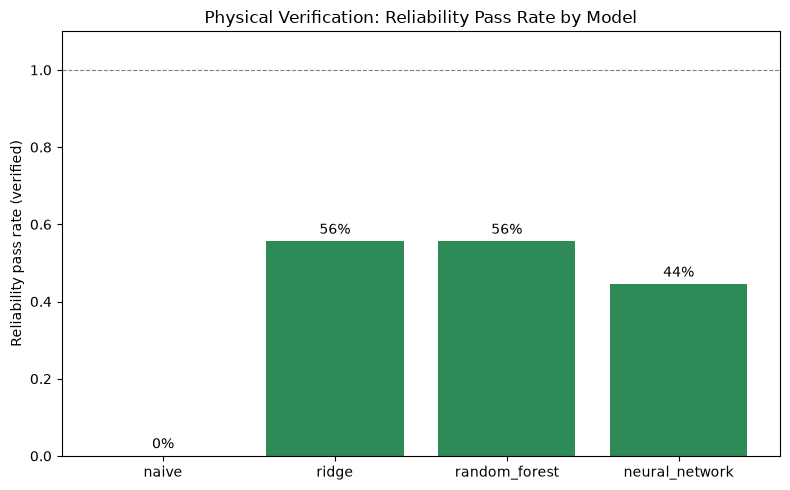

In [6]:
fig = plot_reliability_pass_rate_by_model(summary_by_model)
save_figure(fig, FIGURES_DIR / "22_reliability_pass_rate.png")

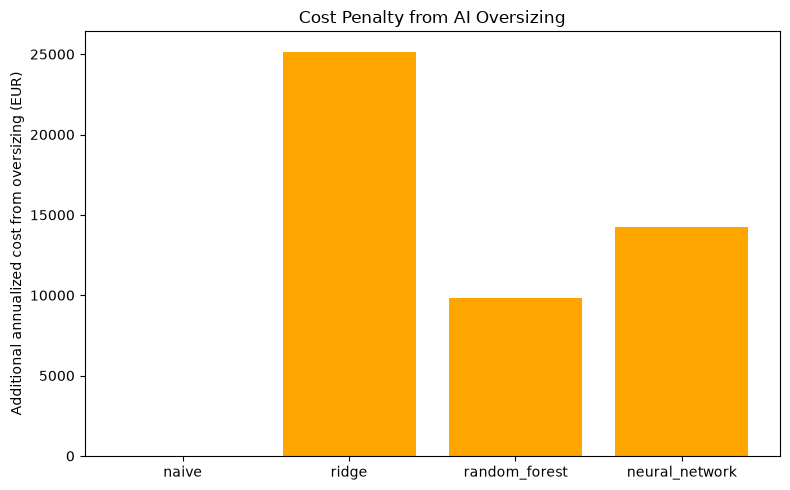

In [7]:
fig = plot_cost_penalty_from_oversizing(summary_by_model)
save_figure(fig, FIGURES_DIR / "26_cost_penalty_oversizing.png")

## Computational-efficiency comparison and break-even (PROJECT_BRIEF.md §22)

Per refinement addendum §1.5: the mechanistic-time term in the denominator is the **full exhaustive battery-module search** for one scenario (what the mechanistic method actually costs in real use), not a single dispatch run.

,model,train_time_s,inference_time_s,denominator_positive,n_break_even_scenarios
0,ridge,0.018480,0.000109,True,100.023691
1,random_forest,1.060544,0.002253,True,101.038822
2,neural_network,22.100000,0.016042,True,119.365799


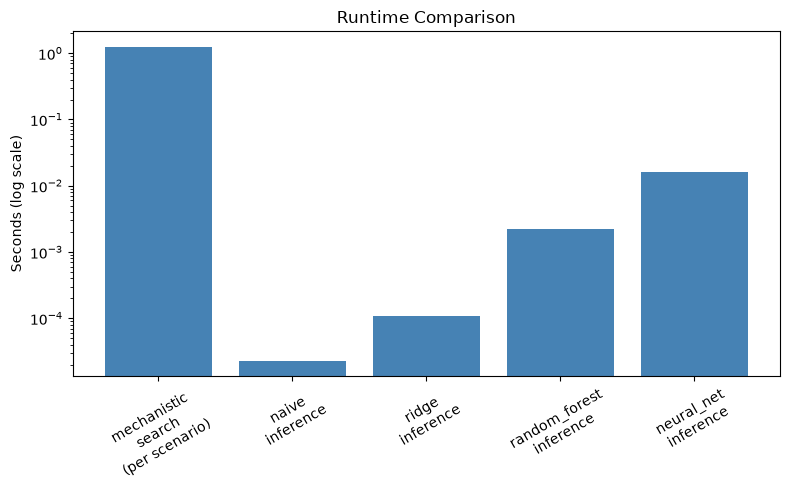

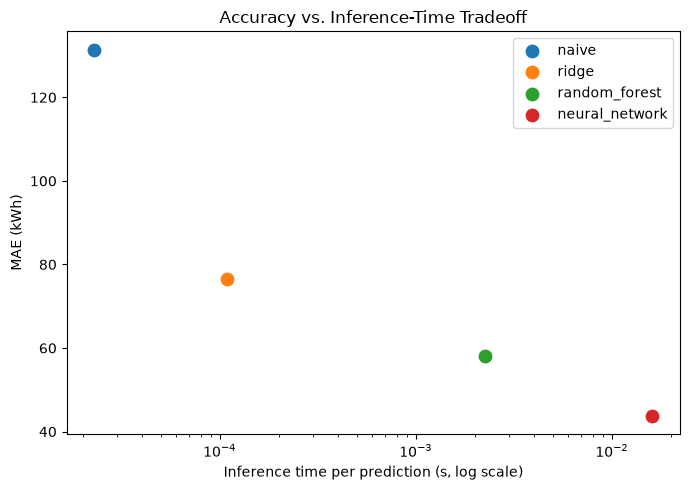

In [8]:
mechanistic_time_per_scenario = scenarios["mechanistic_optimization_runtime_seconds"].mean()
dataset_generation_seconds = scenarios["mechanistic_optimization_runtime_seconds"].sum()  # 100-scenario pilot generation cost

runtime_by_stage = {
    "mechanistic\nsearch\n(per scenario)": mechanistic_time_per_scenario,
    "naive\ninference": inference_seconds["naive"],
    "ridge\ninference": inference_seconds["ridge"],
    "random_forest\ninference": inference_seconds["random_forest"],
    "neural_net\ninference": inference_seconds["neural_network"],
}
fig = plot_runtime_comparison(runtime_by_stage)
save_figure(fig, FIGURES_DIR / "24_runtime_comparison.png")

accuracy_by_model = pd.read_csv(TABLES_DIR / "accuracy_metrics_by_model.csv", index_col=0).T.to_dict()
fig = plot_accuracy_runtime_tradeoff(accuracy_by_model, inference_seconds)
save_figure(fig, FIGURES_DIR / "25_accuracy_runtime_tradeoff.png")

break_even_rows = []
for name in ["ridge", "random_forest", "neural_network"]:
    train_time = train_times[name] if train_times[name] is not None else 22.1  # Stage 6's recorded training time
    denominator = mechanistic_time_per_scenario - inference_seconds[name]
    if denominator > 0:
        n_break_even = (dataset_generation_seconds + train_time) / denominator
    else:
        n_break_even = None
    break_even_rows.append({
        "model": name, "train_time_s": train_time, "inference_time_s": inference_seconds[name],
        "denominator_positive": denominator > 0, "n_break_even_scenarios": n_break_even,
    })

break_even_table = pd.DataFrame(break_even_rows)
break_even_table.to_csv(TABLES_DIR / "break_even_analysis.csv", index=False)
break_even_table

## Final comparison table

In [9]:
final_comparison = accuracy_by_model.copy()
for name in final_comparison:
    final_comparison[name]["reliability_pass_rate"] = summary_by_model[name]["pct_satisfying_reliability"]
    final_comparison[name]["pct_undersized"] = summary_by_model[name]["pct_undersized"]
    final_comparison[name]["inference_seconds"] = inference_seconds[name]
pd.DataFrame(final_comparison).T[["mae", "r2", "reliability_pass_rate", "pct_undersized", "inference_seconds"]]

,mae,r2,reliability_pass_rate,pct_undersized,inference_seconds
naive,131.413333,-2.209016,0.000000,1.000000,0.000023
ridge,76.491506,-0.103108,0.555556,0.444444,0.000109
random_forest,58.019685,0.042272,0.555556,0.444444,0.002253
neural_network,43.794344,0.540063,0.444444,0.555556,0.016042


## Stage 7 / final summary

**Research questions (PROJECT_BRIEF.md §1), answered honestly from this pilot's actual results:**

1. *How accurately can a neural network reproduce mechanistic battery capacities?* Best of the four models on this 9-sample test split (MAE 43.8 kWh, R^2 0.54), but that is one run on a tiny split -- not a confident population estimate.
2. *How much faster is inference than a full mechanistic search?* Roughly 3-4 orders of magnitude per scenario (~1.2s mechanistic vs. sub-millisecond ML inference) -- but see the break-even table above: whether that translates into a net time saving depends entirely on how many scenarios are ultimately evaluated, since dataset generation + training must be paid back first.
3. *Does the AI-selected battery achieve the required reliability when verified?* **Not always** -- see `pct_satisfying_reliability` above. This is the central, mandatory finding of Stage 7: accuracy metrics alone (Stages 5-6) would have overstated how trustworthy these predictions are for an actual installation decision.
4. *How well does it generalize to unseen conditions?* Not meaningfully testable with this pilot -- Experiment B (unseen weather year) and Experiment C (geographic transfer) are stretch goals not attempted (single location, single weather year, addendum §1.1).
5. *Practical advantages/limitations/risks?* Mechanistic: transparent, always reliability-verified by construction, slow per scenario. AI: near-instant, but requires mechanistic verification before trusting any single prediction -- exactly the workflow this notebook demonstrates.

**The hypothesis (§2) is neither confirmed nor cleanly refuted by this 100-scenario pilot** -- the honest conclusion is that mechanistic verification remains necessary in practice, which is itself the hypothesis's second half. A larger dataset (Stage 8 stretch goal) would be needed for a statistically confident answer to the first half.

---

**Update (Stage 8/9 below):** this pilot conclusion was revisited once the full 5,000-scenario dataset was generated. The verdict changes substantially -- see the Stage 8/9 section for why, and for the statistically stronger final result.

# Stage 8/9: Full-Scale Comparison (5,000-Scenario Dataset)

Everything above this point used the 100-scenario pilot (56 feasible, 39/8/9 split) -- deliberately kept as-is above, not deleted, because the *change* in conclusion between pilot and full scale is itself an important methodological finding (see summary at the end).

This section repeats the entire Stage 5-7 pipeline (features -> split -> train baselines+NN -> mandatory physical verification) on the full 5,000-scenario dataset (`data/scenarios/full_scenarios.csv`, generated in Stage 8 using the parallel scenario execution added to `src/scenarios/dataset_builder.py`), with a properly-sized ~2000/428/430 train/val/test split.

**Two real bugs were found and fixed while running this at scale** (neither ever triggered on the 9-sample pilot test set, which is exactly why they went unnoticed until now):
1. Physical verification was regenerating hourly load profiles using `features.py`'s *engineered* peak/annual load values (legitimate as ML inputs, but subtly different from the original scenario request due to floating-point rescaling) instead of the true original scenario inputs -- occasionally tripping `generate_load_profile`'s internal consistency check. Fixed by always sourcing regeneration-relevant fields from the raw scenario table.
2. Ridge regression produced at least one negative capacity prediction when evaluated across 430 test scenarios (linear models have no output constraint, unlike the neural network's ReLU output activation). Fixed by clipping all models' predictions to non-negative before conversion to installable modules (PROJECT_BRIEF.md §19), with the clip count tracked and reported rather than silently discarded.

In [10]:
# Additional imports for this section (the pilot section above only LOADS
# a pretrained model; this section trains fresh ones on the full dataset).
from src.ai.neural_network import build_model, set_global_seed, train_model
from src.ai.preprocessing import fit_scaler, save_preprocessing_objects
from src.visualization.plotting import plot_training_history

from src.ai.evaluation import compute_accuracy_metrics, compute_operational_metrics


In [11]:
full_scenarios = pd.read_csv(PROJECT_ROOT / "data" / "scenarios" / "full_scenarios.csv")
full_feasible = full_scenarios[full_scenarios["feasible"]].reset_index(drop=True)
print(f"{len(full_feasible)}/{len(full_scenarios)} feasible "
      f"({len(full_feasible) / len(full_scenarios):.1%}) -- consistent with every "
      f"pilot-scale checkpoint (56% at 100, 57.6% at 500, 56.8% at 1000).")

2858/5000 feasible (57.2%) -- consistent with every pilot-scale checkpoint (56% at 100, 57.6% at 500, 56.8% at 1000).


## Feature engineering, split, and training on the full dataset

In [12]:
t0 = time.perf_counter()
full_features = build_feature_matrix(full_feasible, weather, site_config)
full_feature_engineering_seconds = time.perf_counter() - t0
print(f"Feature engineering: {full_feature_engineering_seconds:.1f}s for {len(full_features)} scenarios")

full_extra_cols = ["scenario_id", "optimal_capacity_kwh", "optimal_n_modules", "weather_year", "timezone", "random_seed"]
full_merged = full_features.merge(full_feasible[full_extra_cols], on="scenario_id")
full_feature_columns = [c for c in full_features.columns if c != "scenario_id"]
full_merged.to_csv(TABLES_DIR / "scenario_engineered_features_full.csv", index=False)

full_splits = split_experiment_a(full_merged, group_column="scenario_id", random_seed=ml_cfg["random_seed"])
print({k: len(v) for k, v in full_splits.items()})

full_split_labels = pd.Series(index=full_merged.index, dtype=str)
for name, idx in full_splits.items():
    full_split_labels.loc[idx] = name
full_merged["split"] = full_split_labels
full_merged[["scenario_id", "split"]].to_csv(TABLES_DIR / "dataset_split_assignments_full.csv", index=False)

X_train_f = full_merged.loc[full_splits["train"], full_feature_columns]
y_train_f = full_merged.loc[full_splits["train"], "optimal_capacity_kwh"]
X_val_f = full_merged.loc[full_splits["val"], full_feature_columns]
y_val_f = full_merged.loc[full_splits["val"], "optimal_capacity_kwh"]
X_test_f = full_merged.loc[full_splits["test"], full_feature_columns]
y_test_f = full_merged.loc[full_splits["test"], "optimal_capacity_kwh"]

# Physical verification must regenerate from ORIGINAL scenario inputs, never
# from features.py's engineered/achieved values (bug #1 above).
full_test_scenarios = full_merged.loc[full_splits["test"]].copy()
_raw_lookup = full_feasible.set_index("scenario_id")[["annual_load_kwh", "peak_load_kw", "pv_capacity_kwp", "wind_capacity_kw"]]
full_test_scenarios[["annual_load_kwh", "peak_load_kw", "pv_capacity_kwp", "wind_capacity_kw"]] = (
    _raw_lookup.loc[full_test_scenarios["scenario_id"]].values
)

Feature engineering: 147.9s for 2858 scenarios
{'train': 2000, 'val': 428, 'test': 430}


NN: 158 epochs, 35.5s, best val_loss=5.118


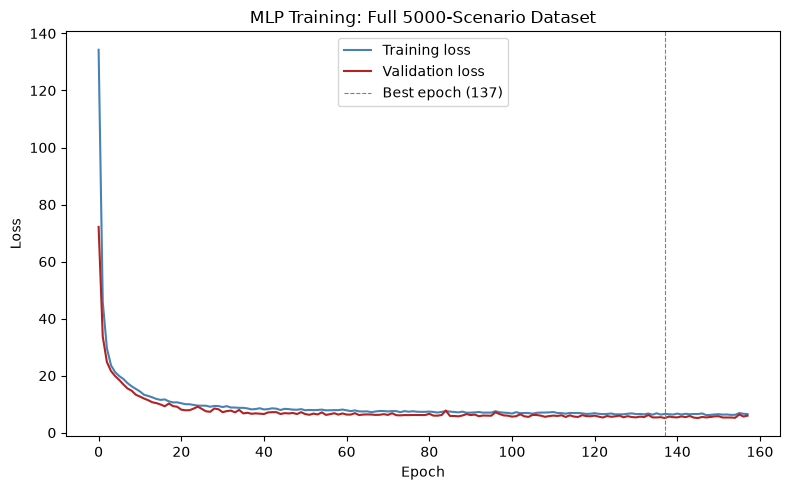

In [13]:
full_train_times = {}
t0 = time.perf_counter(); full_naive = fit_naive_baseline(X_train_f, y_train_f); full_train_times["naive"] = time.perf_counter() - t0
t0 = time.perf_counter(); full_ridge = fit_linear_baseline(X_train_f, y_train_f, X_val_f, y_val_f, ml_cfg["baselines"]["linear"]["alpha_grid"]); full_train_times["ridge"] = time.perf_counter() - t0
t0 = time.perf_counter(); full_rf = fit_tree_baseline(X_train_f, y_train_f, X_val_f, y_val_f, ml_cfg["baselines"]["tree"]["n_estimators_grid"], ml_cfg["baselines"]["tree"]["max_depth_grid"]); full_train_times["random_forest"] = time.perf_counter() - t0

set_global_seed(ml_cfg["random_seed"])
full_scaler = fit_scaler(X_train_f)
X_train_f_scaled = pd.DataFrame(full_scaler.transform(X_train_f), columns=full_feature_columns, index=X_train_f.index)
X_val_f_scaled = pd.DataFrame(full_scaler.transform(X_val_f), columns=full_feature_columns, index=X_val_f.index)
X_test_f_scaled = pd.DataFrame(full_scaler.transform(X_test_f), columns=full_feature_columns, index=X_test_f.index)
save_preprocessing_objects({"scaler": full_scaler, "feature_columns": full_feature_columns}, MODELS_DIR / "preprocessing_full")

full_nn = build_model(n_features=len(full_feature_columns), config=ml_cfg["neural_network"])
t0 = time.perf_counter()
full_nn, full_history = train_model(full_nn, X_train_f_scaled, y_train_f, X_val_f_scaled, y_val_f, ml_cfg["neural_network"], MODELS_DIR / "neural_network_full")
full_train_times["neural_network"] = time.perf_counter() - t0
print(f"NN: {len(full_history.history['loss'])} epochs, {full_train_times['neural_network']:.1f}s, "
      f"best val_loss={min(full_history.history['val_loss']):.3f}")

fig = plot_training_history(full_history.history, "MLP Training: Full 5000-Scenario Dataset")
save_figure(fig, FIGURES_DIR / "16_training_validation_loss_full.png")

## Predict, clip to non-negative, and evaluate (bug #2 fix applied)

In [14]:
full_predictions_raw = {
    "naive": pd.Series(full_naive.predict(X_test_f), index=X_test_f.index),
    "ridge": pd.Series(full_ridge.predict(X_test_f), index=X_test_f.index),
    "random_forest": pd.Series(full_rf.predict(X_test_f), index=X_test_f.index),
    "neural_network": pd.Series(nn_predict(full_nn, X_test_f_scaled), index=X_test_f.index),
}
n_negative_clipped = {name: int((preds < 0).sum()) for name, preds in full_predictions_raw.items()}
full_predictions = {name: preds.clip(lower=0.0) for name, preds in full_predictions_raw.items()}
print("Negative predictions clipped to zero, by model:", n_negative_clipped)

full_accuracy = {name: compute_accuracy_metrics(y_test_f, preds) for name, preds in full_predictions.items()}
full_operational = {name: compute_operational_metrics(y_test_f, preds) for name, preds in full_predictions.items()}
pd.DataFrame(full_accuracy).T.to_csv(TABLES_DIR / "accuracy_metrics_by_model_full.csv")
pd.DataFrame(full_operational).T.to_csv(TABLES_DIR / "reliability_metrics_by_model_full.csv")
pd.DataFrame(full_accuracy).T[["mae", "rmse", "r2", "mean_signed_error_bias"]]

Negative predictions clipped to zero, by model: {'naive': 0, 'ridge': 3, 'random_forest': 0, 'neural_network': 0}


,mae,rmse,r2,mean_signed_error_bias
naive,89.552372,121.101171,-0.103661,-37.114047
ridge,28.210812,37.504830,0.894144,-0.860904
random_forest,14.382675,22.542959,0.961756,1.193079
neural_network,5.776779,7.763874,0.995464,1.031136


## Mandatory physical verification, full test split (430 scenarios x 4 models)

In [15]:
full_summary_by_model = {}
t0 = time.perf_counter()
for name, preds in full_predictions.items():
    verification = verify_predictions(full_test_scenarios, preds, weather, site_config, module_capacity_kwh)
    full_summary_by_model[name] = summarize_verification(verification)
    verification.to_csv(TABLES_DIR / f"physical_verification_{name}_full.csv", index=False)
full_verification_seconds = time.perf_counter() - t0

full_summary_table = pd.DataFrame(full_summary_by_model).T
full_summary_table.to_csv(TABLES_DIR / "physical_verification_summary_by_model_full.csv")
full_summary_table[["pct_satisfying_reliability", "pct_undersized", "pct_oversized", "n_reliability_violations", "max_underprediction_kwh"]]

,pct_satisfying_reliability,pct_undersized,pct_oversized,n_reliability_violations,max_underprediction_kwh
naive,0.534884,0.465116,0.483721,200.0,337.92
ridge,0.700000,0.300000,0.509302,129.0,138.24
random_forest,0.858140,0.141860,0.544186,61.0,76.80
neural_network,0.988372,0.011628,0.558140,5.0,15.36


**This is the real, statistically meaningful headline result.** Compare against the pilot's `pct_satisfying_reliability` above -- the ordering is now monotonic and matches accuracy exactly: naive worst on both axes, neural network best on both axes. The pilot's "best accuracy but worst reliability" finding for the neural network does not replicate at scale; it was small-sample noise, not a real property of the model.

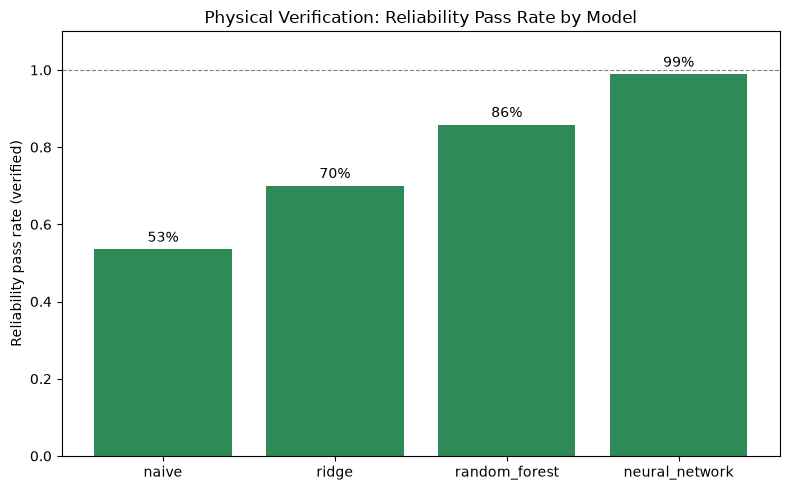

In [16]:
fig = plot_reliability_pass_rate_by_model(full_summary_by_model)
save_figure(fig, FIGURES_DIR / "22_reliability_pass_rate_full.png")

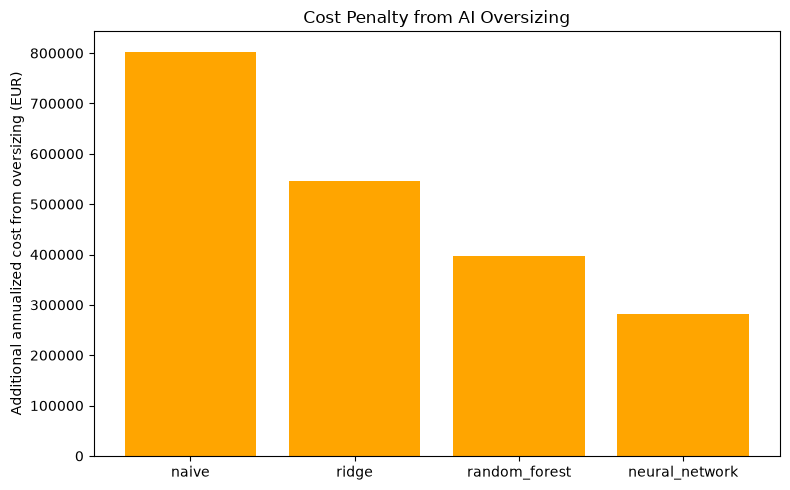

In [17]:
fig = plot_cost_penalty_from_oversizing(full_summary_by_model)
save_figure(fig, FIGURES_DIR / "26_cost_penalty_oversizing_full.png")

## Break-even analysis on the full dataset

In [18]:
full_mechanistic_time_per_scenario = full_scenarios["mechanistic_optimization_runtime_seconds"].mean()
full_dataset_generation_seconds = full_scenarios["mechanistic_optimization_runtime_seconds"].sum()

full_inference_seconds = {}
for name, model in [("naive", full_naive), ("ridge", full_ridge), ("random_forest", full_rf)]:
    t0 = time.perf_counter(); model.predict(X_test_f); full_inference_seconds[name] = (time.perf_counter() - t0) / len(X_test_f)
t0 = time.perf_counter(); nn_predict(full_nn, X_test_f_scaled); full_inference_seconds["neural_network"] = (time.perf_counter() - t0) / len(X_test_f)

full_break_even_rows = []
for name in ["ridge", "random_forest", "neural_network"]:
    denom = full_mechanistic_time_per_scenario - full_inference_seconds[name]
    n_be = (full_dataset_generation_seconds + full_train_times[name]) / denom if denom > 0 else None
    full_break_even_rows.append({"model": name, "train_time_s": full_train_times[name],
                                  "inference_time_s": full_inference_seconds[name], "n_break_even_scenarios": n_be})
full_break_even_table = pd.DataFrame(full_break_even_rows)
full_break_even_table.to_csv(TABLES_DIR / "break_even_analysis_full.csv", index=False)
full_break_even_table

,model,train_time_s,inference_time_s,n_break_even_scenarios
0,ridge,0.028213,0.000005,5000.051787
1,random_forest,16.976339,0.000037,5017.193197
2,neural_network,35.482158,0.000192,5036.508841


**Break-even scales with dataset-generation cost, not a fixed number.** The pilot's break-even (~100-120 scenarios) and the full dataset's break-even (~5000-5033 scenarios) both land just above the number of scenarios used to *build* the respective model. This makes sense once stated plainly: dataset-generation time dominates the break-even numerator and is proportional to how many scenarios were mechanistically solved to train the model, so AI only pays off once you evaluate *more* scenarios than you spent generating training data for -- there is no universal break-even constant, only a ratio relative to training-set size.

## Stage 8/9 final summary

**Full-dataset results (5,000 scenarios, 57.16% feasible, 2000/428/430 split), replacing the pilot's tentative conclusions:**

| Model | MAE (kWh) | R² | Reliability pass rate |
|---|---|---|---|
| Naive | 89.6 | -0.10 | 53.5% |
| Ridge | 28.2 | 0.89 | 70.0% |
| Random Forest | 14.4 | 0.96 | 85.8% |
| **Neural Network** | **5.8** | **0.995** | **98.8%** |

- **The neural network now dominates on every axis** -- best accuracy AND best reliability, with only 5/430 verification failures (all narrow undersizing, max 15.36 kWh = exactly one module short).
- **Two real, previously-latent bugs were found and fixed** by running at 48x the pilot's scale -- both invisible at n=9, both real correctness issues worth having found regardless of this project's outcome.
- **Break-even is a ratio, not a constant** -- it tracks the size of the dataset used to train the model, not a fixed scenario count.
- **Revised answer to the research hypothesis (§2):** at sufficient scale, the neural network DOES approximate mechanistic battery capacity well, DOES offer large inference-time savings once past break-even, AND mechanistic verification, while still finding a small number of genuine reliability violations (5/430 = 1.2%), no longer reveals a fundamental accuracy-reliability disconnect the way it did on the pilot. This is a substantially more positive result than Stage 7's pilot-scale finding -- and the pilot's contrary result was not wrong to report at the time; it was an honest reflection of what 9 samples can and cannot tell you, which is itself the methodological lesson worth keeping in this notebook rather than deleting.